In [ ]:
from pathlib import Path
import json
import re

RUN_DIR = Path("training_runs") / "SPECdroLambda03095_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_BIAS0.5_GG202601271724_13cfe143"

meta = json.loads((RUN_DIR / "meta.json").read_text())
cfg = meta["config"]

# discover seed folders
seed_dirs = sorted(
    [p for p in RUN_DIR.iterdir() if p.is_dir() and p.name.startswith("seed_")],
    key=lambda p: int(re.findall(r"\d+", p.name)[0])
)

print("Found seeds:")
for p in seed_dirs:
    print(" ", p.name)

# choose one
SEED_DIR = seed_dirs[0]   # change index as needed
seed = int(re.findall(r"\d+", SEED_DIR.name)[0])

print("\nUsing seed:", seed)

import pandas as pd

BEST_SYN_PATH = SEED_DIR / "best_synthetic.csv"
assert BEST_SYN_PATH.exists(), f"Missing: {BEST_SYN_PATH}"

syn_df = pd.read_csv(BEST_SYN_PATH)
print("best_synthetic.csv shape:", syn_df.shape)
syn_df.head()


Found seeds:
  seed_42
  seed_123

Using seed: 42


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataset import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = Dataset(
    cfg["dataset_name"],
    multiclass=bool(cfg["multiclass"]),
    minority_id=cfg.get("minority_id"),
    majority_id=cfg.get("majority_id"),
    third_id=cfg.get("third_id"),
    pca_components=int(cfg["pca_components"]),
    seed=seed,
    device=device,
)

x_train, x_val, x_test, y_train, y_val, y_test = ds.get_data_splits(
    train_size=int(cfg["REAL_DATA_SIZE"]),
    bias_pct=float(cfg["BIAS_PCT"]),
    pca_components=int(cfg["pca_components"]),
    drop_protected=False,
    protected_cols=ds.protected_attributes,
)

a_train = ds.a_train
a_val   = ds.a_val
a_test  = ds.a_test



/home/epigou/cs_9170_project/dataset.py:603: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


Label distribution: {0: 23364, 1: 6636}
[TRAIN] size=3000, minority=664 (22.13%)
[VAL] size=6000, minority=1327 (22.12%)
[TEST] size=6000, minority=1327 (22.12%)

TRAIN
 y: {0: np.int64(2336), 1: np.int64(664)}
 a: {0: np.int64(1205), 1: np.int64(1795)}
  a=0, y: {0: np.int64(918), 1: np.int64(287)}
  a=1, y: {0: np.int64(1418), 1: np.int64(377)}

VAL
 y: {0: np.int64(4673), 1: np.int64(1327)}
 a: {0: np.int64(2337), 1: np.int64(3663)}
  a=0, y: {0: np.int64(1789), 1: np.int64(548)}
  a=1, y: {0: np.int64(2884), 1: np.int64(779)}

TEST
 y: {0: np.int64(4673), 1: np.int64(1327)}
 a: {0: np.int64(2372), 1: np.int64(3628)}
  a=0, y: {0: np.int64(1800), 1: np.int64(572)}
  a=1, y: {0: np.int64(2873), 1: np.int64(755)}


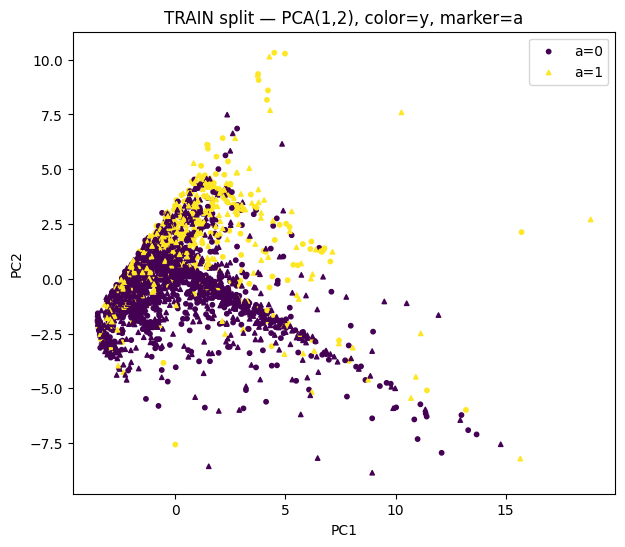

In [3]:
X = x_train.cpu().numpy()
y = y_train.cpu().numpy()
a = a_train.cpu().numpy()

plt.figure(figsize=(7,6))
plt.scatter(X[a==0,0], X[a==0,1], c=y[a==0], s=10, marker="o", label="a=0")
plt.scatter(X[a==1,0], X[a==1,1], c=y[a==1], s=10, marker="^", label="a=1")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("TRAIN split — PCA(1,2), color=y, marker=a")
plt.legend()
plt.show()


Found seeds:
  seed_42
  seed_123

Using seed: 42
best_synthetic.csv shape: (2000, 11)


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,target
0,-2.216237,-0.686951,-0.340346,-0.419186,-0.04815,0.408625,-0.18824,-0.235719,-0.300783,-0.276324,1
1,-2.092431,-0.886951,-0.340346,-0.419186,-0.04815,0.408625,-0.18824,-0.235719,-0.300783,-0.276324,1
2,-2.028812,-0.979047,-0.340346,-0.419186,-0.04815,0.408625,-0.18824,-0.235719,-0.300783,-0.276324,1
3,-1.905669,-0.844225,-0.340346,-0.419186,-0.04815,0.408625,-0.18824,-0.235719,-0.300783,-0.276324,1
4,-1.882775,-1.022011,-0.340346,-0.419186,-0.04815,0.408625,-0.18824,-0.235719,-0.300783,-0.276324,1


/home/epigou/cs_9170_project/dataset.py:603: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


Label distribution: {0: 23364, 1: 6636}
[TRAIN] size=3000, minority=664 (22.13%)
[VAL] size=6000, minority=1327 (22.12%)
[TEST] size=6000, minority=1327 (22.12%)


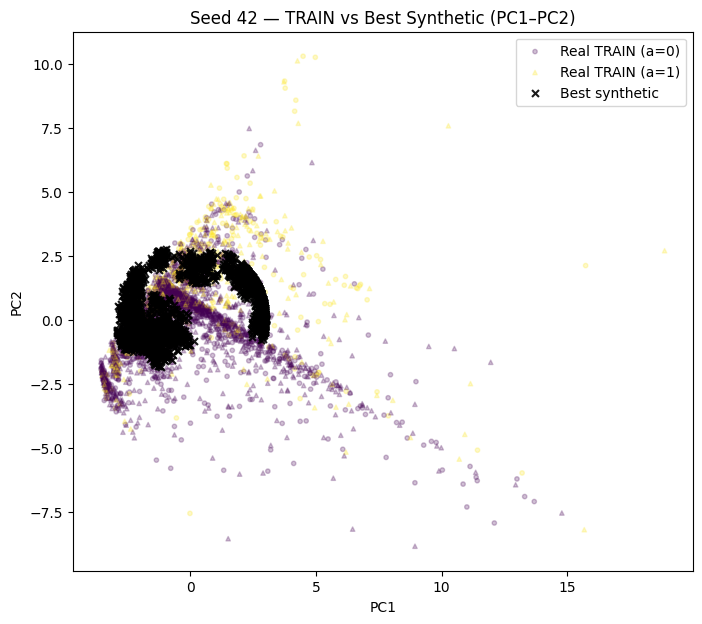

Radius stats:
 Real: min=0.430, p95=7.594, max=28.178
 Synth: min=0.853, p95=3.000, max=3.000


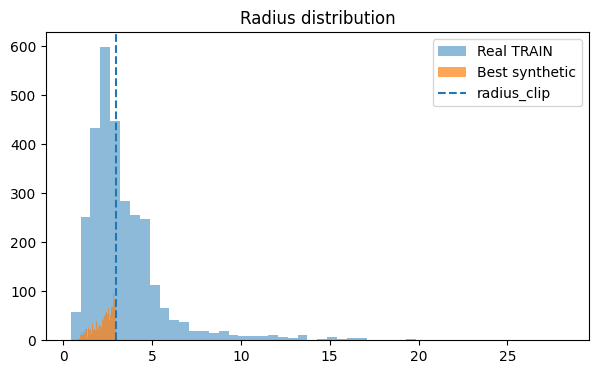

Best synthetic y distribution: {1: 2000}


In [4]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dataset import Dataset

# ============================================================
# 0) Point this at the run folder
# ============================================================
RUN_DIR = Path("training_runs") / "SPECdroLambda03095_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_BIAS0.5_GG202601271724_13cfe143"

meta = json.loads((RUN_DIR / "meta.json").read_text())
cfg = meta["config"]

# ============================================================
# 1) Discover seed folders + choose one
# ============================================================
seed_dirs = sorted(
    [p for p in RUN_DIR.iterdir() if p.is_dir() and p.name.startswith("seed_")],
    key=lambda p: int(re.findall(r"\d+", p.name)[0])
)

print("Found seeds:")
for p in seed_dirs:
    print(" ", p.name)

SEED_DIR = seed_dirs[0]   # change index as needed
seed = int(re.findall(r"\d+", SEED_DIR.name)[0])
print("\nUsing seed:", seed)

# ============================================================
# 2) Load best_synthetic.csv
# ============================================================
BEST_SYN_PATH = SEED_DIR / "best_synthetic.csv"
assert BEST_SYN_PATH.exists(), f"Missing: {BEST_SYN_PATH}"

syn_df = pd.read_csv(BEST_SYN_PATH)
print("best_synthetic.csv shape:", syn_df.shape)
display(syn_df.head())

pca_cols = [c for c in syn_df.columns if c.startswith("pca_")]
assert len(pca_cols) >= 2, f"Expected pca_* columns, found: {pca_cols[:10]}"

Xs = syn_df[pca_cols].values  # [N_syn, A]

# If best_synthetic.csv includes labels, try to pick them up (optional)
y_syn = None
for ycol in ["y", "label", "target", "sampled_target"]:
    if ycol in syn_df.columns:
        y_syn = syn_df[ycol].values
        break

# ============================================================
# 3) Recreate exact data splits via Dataset(seed=seed)
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = Dataset(
    cfg["dataset_name"],
    multiclass=bool(cfg["multiclass"]),
    minority_id=cfg.get("minority_id"),
    majority_id=cfg.get("majority_id"),
    third_id=cfg.get("third_id"),
    pca_components=int(cfg["pca_components"]),
    seed=seed,
    device=device,
)

x_train, x_val, x_test, y_train, y_val, y_test = ds.get_data_splits(
    train_size=int(cfg["REAL_DATA_SIZE"]),
    bias_pct=float(cfg["BIAS_PCT"]),
    pca_components=int(cfg["pca_components"]),
    drop_protected=False,
    protected_cols=ds.protected_attributes,
)

a_train = ds.a_train
a_val   = ds.a_val
a_test  = ds.a_test

Xr = x_train.detach().cpu().numpy()
yr = y_train.detach().cpu().numpy()
ar = a_train.detach().cpu().numpy()

# ============================================================
# 4) Plot: real TRAIN (PC1–PC2) + overlay best synthetic
# ============================================================
plt.figure(figsize=(8,7))

# Real points (faded)
plt.scatter(
    Xr[ar==0,0], Xr[ar==0,1],
    c=yr[ar==0],
    s=10,
    marker="o",
    alpha=0.25,
    label="Real TRAIN (a=0)"
)
plt.scatter(
    Xr[ar==1,0], Xr[ar==1,1],
    c=yr[ar==1],
    s=10,
    marker="^",
    alpha=0.25,
    label="Real TRAIN (a=1)"
)

# Best synthetic overlay
plt.scatter(
    Xs[:,0], Xs[:,1],
    c="black",
    s=25,
    marker="x",
    alpha=0.9,
    label="Best synthetic"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Seed {seed} — TRAIN vs Best Synthetic (PC1–PC2)")
plt.legend()
plt.show()

# ============================================================
# 5) Radius sanity check (helps diagnose OOD / NaN causes)
# ============================================================
r_real = np.linalg.norm(Xr, axis=1)
r_syn  = np.linalg.norm(Xs, axis=1)

print("Radius stats:")
print(f" Real: min={r_real.min():.3f}, p95={np.quantile(r_real,0.95):.3f}, max={r_real.max():.3f}")
print(f" Synth: min={r_syn.min():.3f}, p95={np.quantile(r_syn,0.95):.3f}, max={r_syn.max():.3f}")

plt.figure(figsize=(7,4))
plt.hist(r_real, bins=50, alpha=0.5, label="Real TRAIN")
plt.hist(r_syn,  bins=50, alpha=0.7, label="Best synthetic")
if cfg.get("radius_clip") is not None:
    plt.axvline(float(cfg["radius_clip"]), linestyle="--", label="radius_clip")
plt.title("Radius distribution")
plt.legend()
plt.show()

# ============================================================
# 6) Optional: show synthetic label balance if y exists
# ============================================================
if y_syn is not None:
    unique, counts = np.unique(y_syn, return_counts=True)
    print("Best synthetic y distribution:", dict(zip(unique.tolist(), counts.tolist())))
